<a href="https://colab.research.google.com/github/rahulm8132/CSL701-CE25_Machine-Learning-Lab/blob/main/ML_Experiment_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning Experiment Number 3

**Aim** : To implement a Multiple Linear Regression model from scratch using NumPy matrix operations to predict the selling price of used cars using multiple features from the CarDekho Used Car Dataset.


**Learning Outcomes**
•	Understand the working principle of Multiple Linear Regression.

•	Perform data preprocessing and feature engineering.

•	Convert categorical data into numerical features.

•	Standardize numerical features.

•	Implement the Ordinary Least Squares method using matrix operations.

•	Train and test a regression model without using a ready-made regression function.

•	Evaluate and interpret regression performance using RSS and R².

•	Understand the effect of individual features on the predicted price.



\### Dataset

Use the **CarDekho Used Car Dataset** (`car data.csv`). [CarDekho Used Car Dataset](https://www.kaggle.com/datasets/manishkr1754/cardekho-used-car-data)

Explain meaning of each attribute in this dataset in below comment section :


Here, **Selling_Price** is the target variable.





\# Software/Tools Required

- Python 3.x
- Google Colab / Jupyter Notebook
- NumPy
- Matplotlib

---


### Task 1: Set Up the Python Environment**

- Create a new Google Colab notebook.
- Import **NumPy** for numerical and matrix operations.
- Import **Matplotlib** for data visualization.
- Do not use ready-made machine-learning regression functions such as `LinearRegression()` from Scikit-learn.
- The regression model must be implemented using matrix operations.

---

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Environment setup completed.")
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)

Environment setup completed.
NumPy version: 2.0.2
Pandas version: 2.2.3


## Task 2: Load and Inspect the Dataset

- Download the `car data.csv` file.
- Upload the dataset to Google Colab.
- Load the dataset into Python.
- Display the first few records.
- Determine the number of rows and columns.
- Identify the numerical and categorical attributes.
- Separate `Selling_Price` as the target variable.

---

In [ ]:
# Upload and Load Dataset

from google.colab import files

# Choose dataset file from computer
uploaded = files.upload()

# Get uploaded filename
file_name = list(uploaded.keys())[0]

print("Selected file:", file_name)

# Load CSV file
df = pd.read_csv(file_name)

# Display first 5 records
print("\nFirst 5 records:")
display(df.head())

# Number of rows and columns
print("\nDataset Shape:", df.shape)
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

# Display column names
print("\nColumn Names:")
print(df.columns.tolist())

# Display data types
print("\nData Types:")
print(df.dtypes)

# Numerical attributes
numerical_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

# Categorical attributes
categorical_columns = df.select_dtypes(
    exclude=np.number
).columns.tolist()

print("\nNumerical Attributes:")
print(numerical_columns)

print("\nCategorical Attributes:")
print(categorical_columns)

# Target variable
target = "selling_price"

print("\nTarget Variable:", target)

Saving cardekho_dataset.csv to cardekho_dataset.csv
Selected file: cardekho_dataset.csv

First 5 records:


,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000



Dataset Shape: (15411, 14)
Number of Rows: 15411
Number of Columns: 14

Column Names:
['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']

Data Types:
Unnamed: 0             int64
car_name              object
brand                 object
model                 object
vehicle_age            int64
km_driven              int64
seller_type           object
fuel_type             object
transmission_type     object
mileage              float64
engine                 int64
max_power            float64
seats                  int64
selling_price          int64
dtype: object

Numerical Attributes:
['Unnamed: 0', 'vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']

Categorical Attributes:
['car_name', 'brand', 'model', 'seller_type', 'fuel_type', 'transmission_type']

Target Variable: selling_price


## Task 3: Check and Handle Missing Data

- Check every attribute for missing or null values.
- Count the number of missing values in each column.
- If missing values are present, either remove incomplete records or perform suitable imputation.
- Verify that the final dataset does not contain missing values.
- Record the preprocessing method used.

---

In [ ]:
print("Missing values in each column:")
print(df.isnull().sum())

print("\nTotal missing values:")
print(df.isnull().sum().sum())

# Remove rows containing missing values

if df.isnull().sum().sum() > 0:
    print("\nMissing values found.")

    df = df.dropna().reset_index(drop=True)

    print("Rows containing missing values have been removed.")
else:
    print("\nNo missing values found.")

print("\nDataset shape after preprocessing:")
print(df.shape)

print("\nMissing values after preprocessing:")
print(df.isnull().sum())


Missing values in each column:
Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

Total missing values:
0

No missing values found.

Dataset shape after preprocessing:
(15411, 14)

Missing values after preprocessing:
Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64


## Task 4: Select and Prepare Features

- Examine all available attributes.
- Decide how `Car_Name` should be handled.
- Select meaningful predictor variables for the regression model.
- Create the predictor matrix $X$ and target vector $y$.
- Record the final list of features selected for the model.

---

In [ ]:
selected_features = [
    "vehicle_age",
    "km_driven",
    "mileage",
    "engine",
    "max_power",
    "seats",
    "seller_type",
    "fuel_type",
    "transmission_type"
]

# Predictor dataframe
X_data = df[selected_features].copy()

# Target vector
y_data = df["selling_price"].copy()

print("Selected Features:")
print(selected_features)

print("\nPredictor Dataset:")
display(X_data.head())

print("\nTarget Variable:")
display(y_data.head())

Selected Features:
['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'seller_type', 'fuel_type', 'transmission_type']

Predictor Dataset:


,vehicle_age,km_driven,mileage,engine,max_power,seats,seller_type,fuel_type,transmission_type
0,9,120000,19.70,796,46.30,5,Individual,Petrol,Manual
1,5,20000,18.90,1197,82.00,5,Individual,Petrol,Manual
2,11,60000,17.00,1197,80.00,5,Individual,Petrol,Manual
3,9,37000,20.92,998,67.10,5,Individual,Petrol,Manual
4,6,30000,22.77,1498,98.59,5,Dealer,Diesel,Manual



Target Variable:


,selling_price
0,120000
1,550000
2,215000
3,226000
4,570000


## Task 5: Encode Categorical Variables

Identify the categorical variables:

- `Fuel_Type`
- `Seller_Type`
- `Transmission`

Perform the following:

- Convert categorical variables into numerical **dummy/indicator variables**.
- Verify that all predictors are numerical after encoding.
- Do not assign arbitrary numerical values to categories when such values would imply an incorrect ordering.
- Display the transformed dataset.

---

In [ ]:
categorical_features = [
    "seller_type",
    "fuel_type",
    "transmission_type"
]

# One-hot encoding
X_data = pd.get_dummies(
    X_data,
    columns=categorical_features,
    drop_first=True,
    dtype=float
)

print("Dataset after categorical encoding:")
display(X_data.head())

print("\nColumns after encoding:")
print(X_data.columns.tolist())

print("\nData types:")
print(X_data.dtypes)

# Verify all columns are numerical

all_numerical = all(
    np.issubdtype(dtype, np.number)
    for dtype in X_data.dtypes
)

print("\nAre all predictors numerical?")
print(all_numerical)

Dataset after categorical encoding:


,vehicle_age,km_driven,mileage,engine,max_power,seats,seller_type_Individual,seller_type_Trustmark Dealer,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,transmission_type_Manual
0,9,120000,19.70,796,46.30,5,1.0,0.0,0.0,0.0,0.0,1.0,1.0
1,5,20000,18.90,1197,82.00,5,1.0,0.0,0.0,0.0,0.0,1.0,1.0
2,11,60000,17.00,1197,80.00,5,1.0,0.0,0.0,0.0,0.0,1.0,1.0
3,9,37000,20.92,998,67.10,5,1.0,0.0,0.0,0.0,0.0,1.0,1.0
4,6,30000,22.77,1498,98.59,5,0.0,0.0,1.0,0.0,0.0,0.0,1.0



Columns after encoding:
['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'seller_type_Individual', 'seller_type_Trustmark Dealer', 'fuel_type_Diesel', 'fuel_type_Electric', 'fuel_type_LPG', 'fuel_type_Petrol', 'transmission_type_Manual']

Data types:
vehicle_age                       int64
km_driven                         int64
mileage                         float64
engine                            int64
max_power                       float64
seats                             int64
seller_type_Individual          float64
seller_type_Trustmark Dealer    float64
fuel_type_Diesel                float64
fuel_type_Electric              float64
fuel_type_LPG                   float64
fuel_type_Petrol                float64
transmission_type_Manual        float64
dtype: object

Are all predictors numerical?
True


## Task 6: Perform Feature Engineering

Create a new feature called `Car_Age`.

Calculate it using:

\[
Car\_Age = Current Year - Year
\]

Perform the following:

- Create the `Car_Age` column.
- Display several values of the newly created feature.
- Verify that the calculated ages are reasonable.
- Decide whether the original `Year` feature should be retained.
- Provide a reason for your decision.

---

In [ ]:
df["Car_Age"] = df["vehicle_age"]

print("Sample Car_Age values:")
display(
    df[["vehicle_age", "Car_Age"]].head(10)
)

print("\nCar_Age statistics:")
print(df["Car_Age"].describe())

# Create final feature dataset

X_data = df[
    [
        "Car_Age",
        "km_driven",
        "mileage",
        "engine",
        "max_power",
        "seats",
        "seller_type",
        "fuel_type",
        "transmission_type"
    ]
].copy()

# Encode categorical variables
X_data = pd.get_dummies(
    X_data,
    columns=[
        "seller_type",
        "fuel_type",
        "transmission_type"
    ],
    drop_first=True,
    dtype=float
)

Sample Car_Age values:


,vehicle_age,Car_Age
0,9,9
1,5,5
2,11,11
3,9,9
4,6,6
5,8,8
6,8,8
7,3,3
8,2,2
9,4,4



Car_Age statistics:
count    15411.000000
mean         6.036338
std          3.013291
min          0.000000
25%          4.000000
50%          6.000000
75%          8.000000
max         29.000000
Name: Car_Age, dtype: float64


## Task 7: Perform Exploratory Data Analysis

Perform basic exploratory data analysis using Matplotlib.

- Create a scatter plot of `Present_Price` versus `Selling_Price`.
- Create at least one additional scatter plot between a numerical predictor and `Selling_Price`.
- Label the axes appropriately.
- Add suitable titles to the plots.
- Observe the direction and approximate strength of the relationships.
- Record your observations.

---

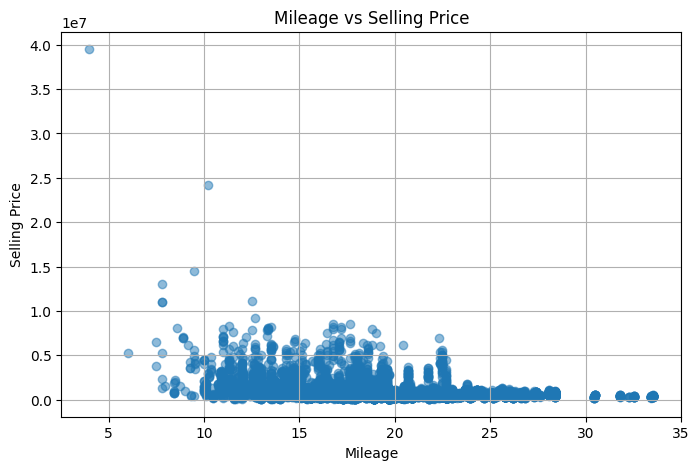

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["mileage"],
    df["selling_price"],
    alpha=0.5
)

plt.xlabel("Mileage")
plt.ylabel("Selling Price")
plt.title("Mileage vs Selling Price")

plt.grid(True)
plt.show()

Scatter Plot 2: Engine vs Selling Price




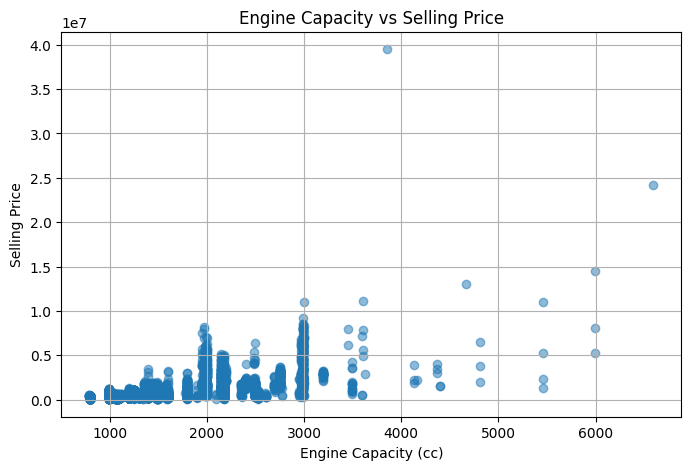

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["engine"],
    df["selling_price"],
    alpha=0.5
)

plt.xlabel("Engine Capacity (cc)")
plt.ylabel("Selling Price")
plt.title("Engine Capacity vs Selling Price")

plt.grid(True)
plt.show()

## Task 8: Standardize Numerical Features

Identify the numerical predictors that need to be standardized.

Use the following standardization equation:

\[
z = ($x$-$\mu$)/$\sigma$
\]

where:

- $x$ = original feature value
- $\mu$ = mean of the feature
- $\sigma$ = standard deviation of the feature

Perform the following:

- Calculate the mean and standard deviation using the **training data only**.
- Standardize the training features.
- Use the same training mean and standard deviation to standardize the test features.
- Do not standardize the target variable `Selling_Price`.

---

In [ ]:
# Identify numerical feature columns
feature_names = X_data.columns.tolist()

# Numerical features
numerical_features = [
    "Car_Age",
    "km_driven",
    "mileage",
    "engine",
    "max_power",
    "seats"
]

# Find their column positions
numerical_indices = [
    feature_names.index(feature)
    for feature in numerical_features
]

# Calculate mean using TRAINING data only
train_mean = np.mean(
    X_train[:, numerical_indices],
    axis=0
)

# Calculate standard deviation using TRAINING data only
train_std = np.std(
    X_train[:, numerical_indices],
    axis=0
)

# Prevent division by zero
train_std[train_std == 0] = 1

# Standardize training data
X_train[:, numerical_indices] = (
    X_train[:, numerical_indices] - train_mean
) / train_std

# Standardize testing data
# using TRAINING mean and standard deviation
X_test[:, numerical_indices] = (
    X_test[:, numerical_indices] - train_mean
) / train_std

print("Numerical features standardized:")
print(numerical_features)

print("\nTraining means:")
print(train_mean)

print("\nTraining standard deviations:")
print(train_std)

print("\nFirst 5 standardized training records:")
print(X_train[:5])


Numerical features standardized:
['Car_Age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']

Training means:
[6.03244646e+00 5.56928196e+04 1.96915518e+01 1.48503739e+03
 1.00516747e+02 5.32624919e+00]

Training standard deviations:
[3.01874714e+00 5.44709544e+04 4.17263296e+00 5.18275963e+02
 4.27439546e+01 8.09570519e-01]

First 5 standardized training records:
[[ 1.97683120e+00  3.17732278e-01  1.60198190e-01 -5.55760666e-01
  -5.05726422e-01 -4.02990451e-01  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00
   1.00000000e+00]
 [-6.73274828e-01  4.23561590e-02  1.84498573e+00 -4.57357492e-01
  -6.20362516e-01 -4.02990451e-01  1.00000000e+00  0.00000000e+00
   1.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   1.00000000e+00]
 [ 3.20514932e-01  7.39975660e-01  2.58457492e-01 -4.57357492e-01
  -2.75050527e-01  2.06745524e+00  0.00000000e+00  0.00000000e+00
   1.00000000e+00  0.00000000e+00  0.00000000e+00  0.000000

## Task 9: Split the Dataset

Divide the dataset into training and testing subsets.

- Use an **80:20 train-test ratio**.
- Randomly select the observations.
- Set a fixed random seed to make the experiment reproducible.
- Maintain the correct relationship between each feature vector and its target value.
- Display the number of observations in the training and testing sets.

---

In [ ]:
# Convert dataframe to NumPy array
X = X_data.to_numpy(dtype=float)

# Convert target to NumPy array
y = y_data.to_numpy(dtype=float)

# Fixed random seed
np.random.seed(42)

# Total observations
n = len(X)

# Randomly shuffle indices
indices = np.random.permutation(n)

# 80% training
train_size = int(0.80 * n)

# Training indices
train_indices = indices[:train_size]

# Testing indices
test_indices = indices[train_size:]

# Create training data
X_train = X[train_indices]
y_train = y[train_indices]

# Create testing data
X_test = X[test_indices]
y_test = y[test_indices]

print("Total observations:", n)

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

print("\nTraining percentage:",
      len(X_train) / n * 100)

print("Testing percentage:",
      len(X_test) / n * 100)

Total observations: 15411
Training observations: 12328
Testing observations: 3083

Training percentage: 79.99480890273182
Testing percentage: 20.005191097268185


## Task 10: Construct the Feature Matrix

Construct the matrices required for regression.

Create:

- $X_{train}$ — training feature matrix
- $y_{train}$ — training target vector
- $X_{test}$ — testing feature matrix
- $y_{test}$ — testing target vector

Verify:

- Number of rows in each matrix.
- Number of predictor columns.
- Shape of the training and testing matrices.

---

In [ ]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("\nX_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

print("\nNumber of predictor columns:",
      X_train.shape[1])

print("\nNumber of training observations:",
      X_train.shape[0])

print("Number of testing observations:",
      X_test.shape[0])

X_train shape: (12328, 13)
y_train shape: (12328,)

X_test shape: (3083, 13)
y_test shape: (3083,)

Number of predictor columns: 13

Number of training observations: 12328
Number of testing observations: 3083


## Task 11: Add the Bias/Intercept Term

Add a leading column containing $1.0$ to both the training and testing feature matrices.

The resulting matrices should contain:

\[
X =
\begin{bmatrix}
1 & x_{11} & x_{12} & \cdots & x_{1p}\\
1 & x_{21} & x_{22} & \cdots & x_{2p}\\
\vdots & \vdots & \vdots & \ddots & \vdots\\
1 & x_{n1} & x_{n2} & \cdots & x_{np}
\end{bmatrix}
\]

Perform the following:

- Add the bias column.
- Verify the new matrix dimensions.
- Understand that the first column represents the intercept $\beta_0$.

---

In [ ]:
# Add column of 1s to training matrix
X_train_bias = np.column_stack(
    (
        np.ones(X_train.shape[0]),
        X_train
    )
)

# Add column of 1s to testing matrix
X_test_bias = np.column_stack(
    (
        np.ones(X_test.shape[0]),
        X_test
    )
)

print("X_train shape before bias:",
      X_train.shape)

print("X_train shape after bias:",
      X_train_bias.shape)

print("\nX_test shape before bias:",
      X_test.shape)

print("X_test shape after bias:",
      X_test_bias.shape)

print("\nFirst 5 rows:")
print(X_train_bias[:5])

X_train shape before bias: (12328, 13)
X_train shape after bias: (12328, 14)

X_test shape before bias: (3083, 13)
X_test shape after bias: (3083, 14)

First 5 rows:
[[ 1.00000000e+00  1.97683120e+00  3.17732278e-01  1.60198190e-01
  -5.55760666e-01 -5.05726422e-01 -4.02990451e-01  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   1.00000000e+00  1.00000000e+00]
 [ 1.00000000e+00 -6.73274828e-01  4.23561590e-02  1.84498573e+00
  -4.57357492e-01 -6.20362516e-01 -4.02990451e-01  1.00000000e+00
   0.00000000e+00  1.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  1.00000000e+00]
 [ 1.00000000e+00  3.20514932e-01  7.39975660e-01  2.58457492e-01
  -4.57357492e-01 -2.75050527e-01  2.06745524e+00  0.00000000e+00
   0.00000000e+00  1.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  1.00000000e+00]
 [ 1.00000000e+00 -1.66706459e+00 -9.39818665e-01 -3.09529203e-01
   2.50110103e-02  4.40606231e-01 -4.02990451e-01  0.00000000e+00
   

## Task 12: Implement the OLS Function

Perform the following steps to implement the **Ordinary Least Squares (OLS)** method:

- Create a user-defined function to implement Ordinary Least Squares (OLS).
- Calculate the matrix $X^TX$.
- Calculate the matrix $X^T y$.
- Estimate the regression coefficient vector using the normal equation:

: β̂ = (XᵀX)⁻¹Xᵀy.

- Return the calculated coefficient vector.
- Use **NumPy matrix operations** to perform the calculations.
- Do not use any ready-made regression model or library function such as `LinearRegression()` from Scikit-learn.\

In [ ]:
def ols(X, y):

    # Calculate X transpose
    X_T = X.T

    # Calculate X^T X
    XTX = X_T @ X

    # Calculate X^T y
    XTy = X_T @ y

    # Calculate beta
    beta = np.linalg.solve(XTX, XTy)

    return beta


# Train the model
beta = ols(X_train_bias, y_train)

print("OLS coefficient vector:")
print(beta)

OLS coefficient vector:
[ 994217.80724365 -195163.09053546  -34965.02601204   62397.2943623
   48021.8182965   644333.49945541    6812.17431665   -6783.55536347
  -78002.67281776 -124692.42956251  -96756.41053174  358735.63796481
 -119859.21560939 -121450.23037614]


## Task 13: Check Matrix Singularity

- Calculate the determinant of $X^T X$.
- Check whether the determinant is zero or sufficiently close to zero.
- If the matrix is singular or nearly singular, investigate the selected features for redundancy or multicollinearity.
- Modify the feature set if required.
- Record your observations.


In [ ]:
# Calculate X^T X
XTX = X_train_bias.T @ X_train_bias

# Calculate determinant
det_XTX = np.linalg.det(XTX)

print("Determinant of X^T X:")
print(det_XTX)

# Check singularity
if np.isclose(det_XTX, 0):
    print("\nX^T X is singular or nearly singular.")
    print("Check for redundant features or multicollinearity.")
else:
    print("\nX^T X is non-singular.")
    print("OLS can be calculated.")

# Additional numerical stability check

condition_number = np.linalg.cond(XTX)

print("\nCondition number:")
print(condition_number)

if condition_number > 1e10:
    print("Warning: Matrix may have strong multicollinearity.")
else:
    print("Matrix condition is acceptable.")


Determinant of X^T X:
4.028687647671399e+43

X^T X is non-singular.
OLS can be calculated.

Condition number:
11706.366913708265
Matrix condition is acceptable.


## Task 14: Train the Regression Model

- Apply the OLS function to the training dataset.
- Obtain the regression coefficient vector $\hat{\beta}$.
- Display the intercept coefficient $\beta_0$.
- Display the coefficient corresponding to each feature.
- Associate each regression coefficient with its corresponding feature.

In [ ]:
# Calculate beta coefficients
beta = ols(X_train_bias, y_train)

# Create feature names
coefficient_names = [
    "Intercept"
] + feature_names

print("Regression Coefficients:\n")

for name, coefficient in zip(
    coefficient_names,
    beta
):
    print(
        f"{name:30s} : {coefficient:.6f}"
    )

Regression Coefficients:

Intercept                      : 994217.807244
Car_Age                        : -195163.090535
km_driven                      : -34965.026012
mileage                        : 62397.294362
engine                         : 48021.818296
max_power                      : 644333.499455
seats                          : 6812.174317
seller_type_Individual         : -6783.555363
seller_type_Trustmark Dealer   : -78002.672818
fuel_type_Diesel               : -124692.429563
fuel_type_Electric             : -96756.410532
fuel_type_LPG                  : 358735.637965
fuel_type_Petrol               : -119859.215609
transmission_type_Manual       : -121450.230376


## Task 15: Interpret the Regression Coefficients

- Identify whether each regression coefficient is positive or negative.
- Explain what the sign of each coefficient indicates.
- Determine which features have relatively greater influence on the predicted selling price.
- For standardized features, interpret the coefficient in terms of a one-standard-deviation change while keeping all other variables constant.

In [ ]:
print("Coefficient Interpretation:\n")

for name, coefficient in zip(
    coefficient_names,
    beta
):

    if name == "Intercept":
        print(
            f"{name}: {coefficient:.4f}"
        )

    elif coefficient > 0:
        print(
            f"{name}: {coefficient:.4f} "
            f"-> Positive effect"
        )

    elif coefficient < 0:
        print(
            f"{name}: {coefficient:.4f} "
            f"-> Negative effect"
        )

    else:
        print(
            f"{name}: {coefficient:.4f} "
            f"-> No effect"
        )

Coefficient Interpretation:

Intercept: 994217.8072
Car_Age: -195163.0905 -> Negative effect
km_driven: -34965.0260 -> Negative effect
mileage: 62397.2944 -> Positive effect
engine: 48021.8183 -> Positive effect
max_power: 644333.4995 -> Positive effect
seats: 6812.1743 -> Positive effect
seller_type_Individual: -6783.5554 -> Negative effect
seller_type_Trustmark Dealer: -78002.6728 -> Negative effect
fuel_type_Diesel: -124692.4296 -> Negative effect
fuel_type_Electric: -96756.4105 -> Negative effect
fuel_type_LPG: 358735.6380 -> Positive effect
fuel_type_Petrol: -119859.2156 -> Negative effect
transmission_type_Manual: -121450.2304 -> Negative effect


In [ ]:
# Compare coefficient magnitudes

coefficient_table = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": beta[1:],
    "Absolute_Coefficient": np.abs(beta[1:])
})

coefficient_table = coefficient_table.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

print("Feature influence:")
display(coefficient_table)

Feature influence:


,Feature,Coefficient,Absolute_Coefficient
4,max_power,644333.499455,644333.499455
10,fuel_type_LPG,358735.637965,358735.637965
0,Car_Age,-195163.090535,195163.090535
8,fuel_type_Diesel,-124692.429563,124692.429563
12,transmission_type_Manual,-121450.230376,121450.230376
11,fuel_type_Petrol,-119859.215609,119859.215609
9,fuel_type_Electric,-96756.410532,96756.410532
7,seller_type_Trustmark Dealer,-78002.672818,78002.672818
2,mileage,62397.294362,62397.294362
3,engine,48021.818296,48021.818296


## Task 16: Predict Selling Prices

- Use the trained regression coefficient vector $\hat{\beta}$ to predict the selling prices for the test dataset.
- Calculate the predicted values using the equation: ŷ_test = X_test β̂.

- Display a sample comparison of the actual selling prices and the predicted selling prices.

In [ ]:
# Prediction equation:
# y_hat = X_test * beta

y_pred = X_test_bias @ beta

# Create comparison table
prediction_table = pd.DataFrame({
    "Actual Selling Price": y_test,
    "Predicted Selling Price": y_pred
})

# Calculate prediction error

prediction_table["Error"] = (
    prediction_table["Actual Selling Price"]
    - prediction_table["Predicted Selling Price"]
)

print("Actual vs Predicted Selling Prices:")
display(prediction_table.head(10))

Actual vs Predicted Selling Prices:


,Actual Selling Price,Predicted Selling Price,Error
0,4450000.0,2.046440e+06,2.403560e+06
1,1290000.0,1.431418e+06,-1.414178e+05
2,485000.0,3.390972e+05,1.459028e+05
3,400000.0,5.432682e+05,-1.432682e+05
4,800000.0,8.623530e+05,-6.235298e+04
5,150000.0,-6.165112e+05,7.665112e+05
6,650000.0,8.209350e+05,-1.709350e+05
7,325000.0,-1.758146e+05,5.008146e+05
8,300000.0,3.786409e+05,-7.864092e+04
9,925000.0,7.769197e+05,1.480803e+05


## Task 17: Calculate Prediction Errors and RSS

- Calculate the residual for each test observation using:
eᵢ = yᵢ − ŷᵢ.

- Calculate the **Residual Sum of Squares (RSS): RSS = Σ(yᵢ − ŷᵢ)².

- Display the calculated RSS value.
- Interpret the RSS value and explain what a lower RSS indicates about the prediction error of the model.

In [ ]:
# Calculate residuals
residuals = y_test - y_pred

# Calculate RSS
RSS = np.sum(
    residuals ** 2
)

print("Residual Sum of Squares (RSS):")
print(RSS)

print("\nRSS interpretation:")
print(
    "A lower RSS means that the total squared "
    "prediction error is lower."
)

Residual Sum of Squares (RSS):
885105657669987.2

RSS interpretation:
A lower RSS means that the total squared prediction error is lower.


## Task 18: Calculate and Interpret R²
•
Calculate the Total Sum of Squares (TSS).

•
Calculate R² = 1 − RSS/TSS.

•
Display the R² value.

•
Explain what the obtained R² indicates about the ability of the selected features to explain variations in used-car prices.



In [ ]:
# Mean of actual test prices
y_test_mean = np.mean(y_test)

# Total Sum of Squares
TSS = np.sum(
    (y_test - y_test_mean) ** 2
)

# R²
R2 = 1 - (RSS / TSS)

print("Total Sum of Squares (TSS):")
print(TSS)

print("\nResidual Sum of Squares (RSS):")
print(RSS)

print("\nR²:")
print(R2)

print(
    f"\nR² Percentage: {R2 * 100:.2f}%"
)

Total Sum of Squares (TSS):
2407385049859876.5

Residual Sum of Squares (RSS):
885105657669987.2

R²:
0.6323373123375069

R² Percentage: 63.23%


### Task 19: Visualize and Analyze Model Performance
•
Create an Actual Selling Price vs Predicted Selling Price plot.

•
Add a reference line representing perfect prediction.

•
Plot or examine the residuals.

•
Identify observations with relatively large prediction errors.

•
Comment on whether the errors appear randomly distributed.

•
Discuss possible reasons for prediction errors.


Actual vs Predicted Plot

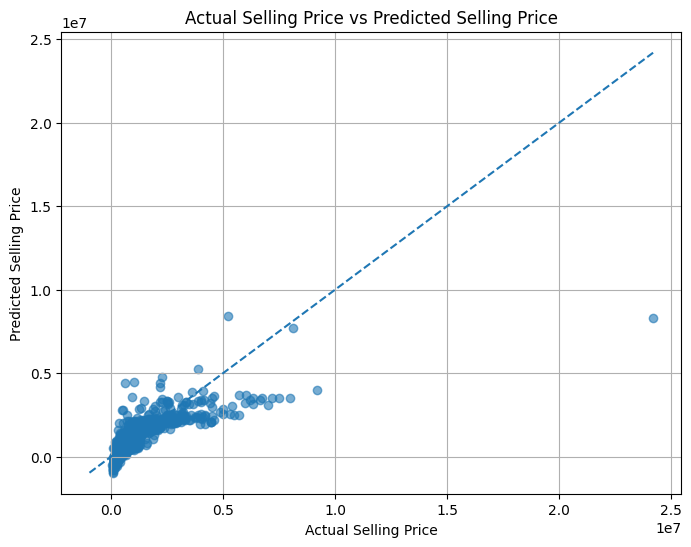

In [ ]:
# Task 19: Actual vs Predicted Plot

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

# Perfect prediction line
minimum = min(
    y_test.min(),
    y_pred.min()
)

maximum = max(
    y_test.max(),
    y_pred.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")

plt.title(
    "Actual Selling Price vs Predicted Selling Price"
)

plt.grid(True)

plt.show()

Residual Plot

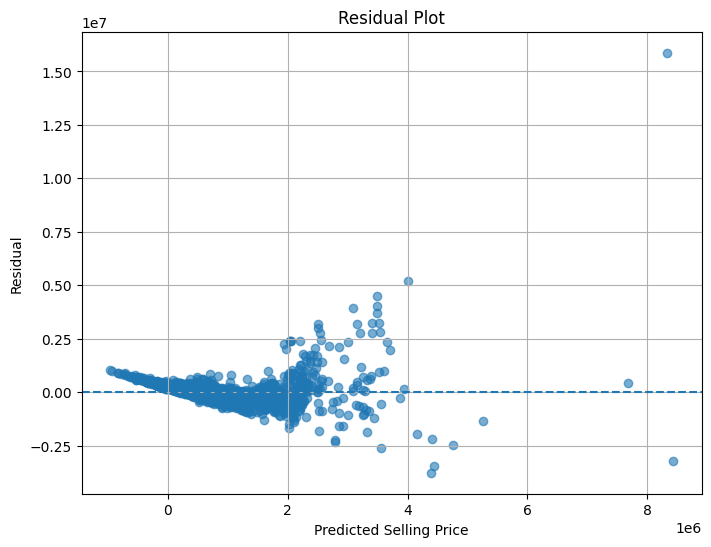

In [ ]:
# Residual Plot

plt.figure(figsize=(8, 6))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.6
)

# Zero residual reference line
plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Selling Price")
plt.ylabel("Residual")

plt.title("Residual Plot")

plt.grid(True)

plt.show()

Find Large Prediction Errors

In [ ]:
# Find observations with large prediction errors

prediction_table["Absolute_Error"] = np.abs(
    prediction_table["Error"]
)

large_errors = prediction_table.sort_values(
    by="Absolute_Error",
    ascending=False
)

print("10 observations with largest prediction errors:")

display(
    large_errors.head(10)
)

10 observations with largest prediction errors:


,Actual Selling Price,Predicted Selling Price,Error,Absolute_Error
2796,24200000.0,8.323205e+06,1.587679e+07,1.587679e+07
2362,9200000.0,4.009019e+06,5.190981e+06,5.190981e+06
1382,8000000.0,3.488917e+06,4.511083e+06,4.511083e+06
841,7500000.0,3.485714e+06,4.014286e+06,4.014286e+06
246,7000000.0,3.084722e+06,3.915278e+06,3.915278e+06
26,625000.0,4.390874e+06,-3.765874e+06,3.765874e+06
1286,7199000.0,3.488917e+06,3.710083e+06,3.710083e+06
2528,999000.0,4.439605e+06,-3.440605e+06,3.440605e+06
2050,5200000.0,8.434193e+06,-3.234193e+06,3.234193e+06
1092,6645000.0,3.412468e+06,3.232532e+06,3.232532e+06


### Task 20: Conclude
•
Comment on the most influential features.

•
Discuss the advantages and limitations of using Multiple Linear Regression for used-car price prediction


### Conclusion
Conclude the experiment by stating whether the Multiple Linear Regression model implemented using the OLS normal equation was able to predict used-car selling prices effectively. The conclusion should include the obtained RSS and R² values, observations regarding important features, the effect of preprocessing and feature engineering, and the limitations of using a linear regression model for real-world used-car price prediction.

Conclusion / Final Analysis

In [ ]:
print("=" * 70)
print("MULTIPLE LINEAR REGRESSION - CARDEKHO USED CAR DATASET")
print("=" * 70)

print("\nDataset Information")
print("-------------------")

print("Total observations:", len(X))
print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

print("\nNumber of predictors:",
      len(feature_names))

print("\nModel Performance")
print("-----------------")

print(f"RSS : {RSS:.4f}")
print(f"TSS : {TSS:.4f}")
print(f"R²  : {R2:.4f}")
print(f"R²% : {R2 * 100:.2f}%")

print("\nRegression Coefficients")
print("-----------------------")

for name, coefficient in zip(
    coefficient_names,
    beta
):
    print(
        f"{name:30s}: {coefficient:.6f}"
    )

print("\nMost Influential Features")
print("-------------------------")

display(
    coefficient_table.head(5)
)

MULTIPLE LINEAR REGRESSION - CARDEKHO USED CAR DATASET

Dataset Information
-------------------
Total observations: 15411
Training observations: 12328
Testing observations: 3083

Number of predictors: 13

Model Performance
-----------------
RSS : 885105657669987.2500
TSS : 2407385049859876.5000
R²  : 0.6323
R²% : 63.23%

Regression Coefficients
-----------------------
Intercept                     : 994217.807244
Car_Age                       : -195163.090535
km_driven                     : -34965.026012
mileage                       : 62397.294362
engine                        : 48021.818296
max_power                     : 644333.499455
seats                         : 6812.174317
seller_type_Individual        : -6783.555363
seller_type_Trustmark Dealer  : -78002.672818
fuel_type_Diesel              : -124692.429563
fuel_type_Electric            : -96756.410532
fuel_type_LPG                 : 358735.637965
fuel_type_Petrol              : -119859.215609
transmission_type_Manual      : -

,Feature,Coefficient,Absolute_Coefficient
4,max_power,644333.499455,644333.499455
10,fuel_type_LPG,358735.637965,358735.637965
0,Car_Age,-195163.090535,195163.090535
8,fuel_type_Diesel,-124692.429563,124692.429563
12,transmission_type_Manual,-121450.230376,121450.230376
